In [ ]:
from analyzer import * 
import seaborn as sns 

sns.set_theme(
    style="whitegrid",
    context="paper",
)  

mm = MMStarResults()
mms = mm.get_quadrants()
mms[mms['finetuned'] == 'Pretrained'].groupby("cc_quadrant")["MG"].agg(['count', 'mean']).to_latex('./tables/quadrant-mmstar.tex', float_format="%.1f")  

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.human['correct'] = self.human['correct'] * 100


14 6
[]


In [ ]:
vv = VQAResults()   
vvs= vv.quadrants() 
vvs[vvs['finetuned'] == 'Pretrained'].groupby("cc_quadrant")["MG"].agg(['count', 'mean']).to_latex('./tables/quadrant-vqa.tex', float_format="%.1f") 

In [ ]:
vvs['dataset'] = 'VQAv2' 
mms['dataset'] = 'MMStar'

pd.concat([vvs, mms]).pivot_table(
    index=['cc_quadrant'] , 
    values=['MG'] , 
    columns=['dataset'] , 
    aggfunc = ['count', 'mean'] ).to_latex('./tables/quadrant-stats.tex', float_format="%.1f") 

In [ ]:

model = vv.model 
model.finetuned.unique()   
vqadf, vqapt = vv.finetuning_effect(test_model) 
vqadf = vqadf.melt(id_vars=['model', 'finetuned', 'model_size', 'question_id', 'answer_type', 'question_type'], value_vars=['delta_acc', 'delta_sim'], var_name='score_type', value_name='delta') 
# vqadf.groupby(['model', 'finetuned', 'model_size', 'score_type']).count()
vqa=vqadf.pivot_table(index=['model', 'finetuned', 'model_size'], columns=['answer_type'], values=['delta']).droplevel(0, axis=1) 

model_mg = vv.model_mg
test_model_mg = vv.test_model_mg # get_mg(test_model, filename='5k-test')   

In [ ]:

test_model = vv.test_model 
human_vqa = vv.human 
vqq['dataset'] = 'VQAv2' 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  

In [3]:

dfdf = mm.finetuning_effect(mm.test_model)
dfdf.groupby(['model', 'finetuned'])[['correct', 'correct_baseline']].count()

mmstar = dfdf.pivot_table(
    index=['model', 'finetuned'], # ['model', 'family', 'model_size', 'finetuned'], 
    values='delta', 
    aggfunc='mean'
).reset_index() 


In [2]:
import matplotlib.pyplot as plt 

dfdf.pivot_table(
    index=['model', 'finetuned'], 
    columns='category', 
    values='delta', 
    aggfunc='mean'
).to_csv("./tables/appendix-mmstar-category-heatmap.csv") 

plt.figure(figsize=(7,7))
pt = dfdf.pivot_table(
    index=['model', 'finetuned'], 
    columns='category', 
    values='delta', 
    aggfunc='mean'
)
ax = sns.heatmap(pt, 
    annot=True,
    fmt=".1f",
    cmap="RdBu_r", # 
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Δ Score "}
)
# ax.set_xticklabels(categories, rotation=0)
# ax.set_yticklabels(models, rotation=0)
# plt.title("Blind Training Improves Reasoning-Oriented Categories", pad=10)
plt.tight_layout()
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 700x700 with 0 Axes>

OSError: Cannot save file into a non-existent directory: 'tables/appendix'

In [ ]:
qmg = pd.concat([vqq, mms]).reset_index()
# qmg= qmg[qmg['finetuned'] == "Pretrained"]  
qmg.pivot_table(index=['model', 'cc_quadrant'], columns=['dataset'], values=['MG'], aggfunc=['mean', 'count'])

<Axes: xlabel='cc_quadrant', ylabel='MG'>

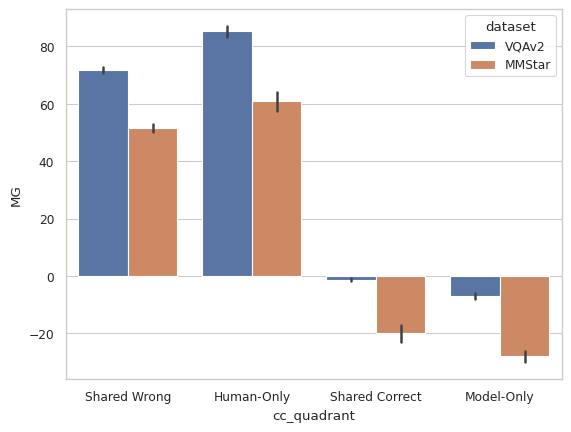

In [7]:
sns.barplot(qmg, x='cc_quadrant', y='MG', hue='dataset') 

In [12]:

pd.merge(mmstar, vqa.reset_index(), on=['model', 'finetuned'], suffixes=(' MMStar', ' VQA')) 

,model,finetuned,delta,model_size,number,other,yes/no
0,InternVL 3.5 (8B),JS VQA (GT),7.608696,8,-0.141385,1.090516,-0.123176
1,InternVL 3.5 (8B),JS-Blind MMStar (n=15),9.299517,8,0.172846,-0.027225,-0.119810
2,InternVL 3.5 (8B),JS-Blind VQA (n=10),7.729469,8,0.090308,0.522691,-0.755010
3,InternVL 3.5 (8B),JS-Blind VQA (n=15),7.850242,8,0.205385,0.398710,-0.820092
4,InternVL 3.5 (8B),SFT-Blind MMStar (n=15),7.487923,8,-0.122231,0.323939,-0.210560
5,InternVL 3.5 (8B),SFT-Blind VQA,7.850242,8,-0.191846,0.481739,-0.657734
6,InternVL 3.5 (8B),SFT-VQA,8.212560,8,-0.186538,1.048149,-0.051259
7,LLaVA‑Mistral (7B),JS VQA (GT),2.633679,7,-0.331923,-1.237583,-0.449383
8,LLaVA‑Mistral (7B),JS-Blind MMStar (n=15),5.107741,7,0.117923,-0.651705,0.034250
9,LLaVA‑Mistral (7B),JS-Blind VQA (n=10),2.793296,7,-0.381154,-2.153369,-0.321480


### Correlations 

In [ ]:
res_HH, res_MM, res_HM  = get_agreements(human_vqa, model_vqa, n_boot=0)  # accuarcy 
corr_mat = get_all_cm(res_HH, res_MM, res_HM )
acc_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='acc_corr') 
plot_unified_agreement_heatmap(corr_mat, res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Accuracy)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-acc.png') 
acc = pd.concat([result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)]) 

res_HH['corr_mat'].mean().reset_index().to_csv('./corr/acc-humans-n6.csv', encoding="utf-8-sig")
res_MM['corr_mat'].mean().reset_index().to_csv('./corr/acc-models-toM.csv', encoding="utf-8-sig")
res_HM['corr_mat'].mean().reset_index().to_csv('./corr/acc-models-toH-n6.csv', encoding="utf-8-sig")

In [ ]:
res_HH, res_MM, res_HM  =  get_agreements(human_vqa, model_vqa, 'answer_similarity', n_boot=0) 
corr_mat = get_all_cm(res_HH, res_MM, res_HM ) 
sim_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='sim_corr') 
pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
acc = pd.concat([acc, result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)])
plot_unified_agreement_heatmap(corr_mat,  res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Emb Similarity)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-sim.png') 
transform_corr_table(acc) # .to_latex('./tables/appendix/3_spearman-interrater-vqa-finetuned.tex', float_format="%.3f")   

In [ ]:

if isinstance(mg_df.columns, pd.MultiIndex):
    mg_df.columns = ['_'.join(str(c) for c in col if c != '') for col in mg_df.columns.values]

In [ ]:
# from utils.plots import scatterplot, get_family, parse_size 
from utils.plots import scatterplot_finetuned 
import pandas as pd
from utils.corr import corr_by_regime

pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr= pd.merge(pcorr.reset_index(), mg_df.reset_index(), on=['model'])  
pcorr = pcorr[~pcorr['model'].str.contains('MMStar')]
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]

pcorr = pcorr[~pcorr['model'].str.contains('|'.join(exclude_models))]
corr_by_regime(pcorr).to_latex('./tables/appendix/finetuned-pearson-r.tex', float_format="%.1f")    

for fam in pcorr.family.unique(): 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='acc_corr', y_col='MG_Acc', title=f'{fam} accuracy') # 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='sim_corr', y_col='MG_S', title=f'{fam} similairty') # 

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(
    pt,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    # vmin=0, vmax=1,
    linewidths=0.5
)
plt.ylabel("Model")
plt.xlabel("Spurious correlation type")
plt.title("Accuracy by model and spurious correlation type")
plt.tight_layout()
plt.show() # spu-corr-finetune.png

In [ ]:

 
df2 = pd.concat([df, meta], axis=1)
pt = (
    df2.groupby(['model', 'trainer', 'supervision', 'dataset'])['delta']
       .mean()
       .unstack(['supervision', 'dataset'])
       .round(3)
) 